# V61: Improved Graph Logic - Relaxed MIS with Min Assets Constraint

## Tujuan Eksperimen

Notebook ini membandingkan **Original Graph vs Improved Graph** dengan Relaxed MIS:

### Problem dari V60:
- **Static (All Assets)**: 70.50% return ✅
- **Graph Diversify**: 45.27% return ❌ (-35%)
- **Graph Cluster**: 15.85% return ❌ (-77%)

**Root Cause**: MIS terlalu agresif → terlalu sedikit aset → missed opportunities

### Improvement: Relaxed MIS

**Key Innovation:**
1. **Min Assets Constraint**: Pastikan minimal N aset terpilih
2. **Relaxed Threshold**: Jika kurang aset, relax correlation threshold
3. **Incremental Selection**: Tambah aset secara iteratif sampai min threshold

### Strategi yang Dibandingkan:

1. **Static Markowitz (Baseline)**
   - All assets, no filtering

2. **Original Graph Diversify (V60)**
   - Standard MIS, korelasi ≤ 0.4
   - Problem: Too few assets

3. **Improved Relaxed Diversify** 🆕
   - Relaxed MIS dengan min_assets=12
   - Adaptive correlation threshold

4. **Original Graph Cluster (V60)**
   - Standard MIS, korelasi ≥ 0.4
   - Problem: Too few assets

5. **Improved Relaxed Cluster** 🆕
   - Relaxed MIS dengan min_assets=12
   - Adaptive correlation threshold

### Hipotesis:
- **H1:** Relaxed MIS outperform Original MIS
- **H2:** Min assets constraint reduces concentration risk
- **H3:** Improved graph closer to Static baseline

### Parameter:
- Min Assets: 12 (dari ~45 total assets)
- Base Correlation Threshold: 0.4
- Relaxed Threshold: 0.55 (if needed)
- Transaction Fee: 0.25%
- Rebalancing: 20 hari

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

test_dates = returns.loc[returns.index.year == 2025].index

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")
print(f"Test period: {test_dates[0]} to {test_dates[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00
Test period: 2025-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# Markowitz Optimization Function

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Markowitz optimization function defined!")

Markowitz optimization function defined!


In [4]:
# Asset Selection Methods

def get_all_assets(returns_window, corr_threshold=None):
    """Baseline: All Assets"""
    return list(returns_window.columns)

# ===== ORIGINAL GRAPH (V60 - Problematic) =====

def get_assets_original_diversify(returns_window, corr_threshold=0.4):
    """Original Graph Diversify (from V60) - Too Aggressive"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        assets = list(returns_window.columns)
    else:
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    selected = list(nx.approximation.maximum_independent_set(G))
    print(f"  Original Diversify: {len(selected)} assets selected")
    return selected

def get_assets_original_cluster(returns_window, corr_threshold=0.4):
    """Original Graph Cluster (from V60) - Too Aggressive"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        assets = list(returns_window.columns)
    else:
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    selected = list(nx.approximation.maximum_independent_set(G))
    print(f"  Original Cluster: {len(selected)} assets selected")
    return selected

# ===== IMPROVED RELAXED MIS =====

def get_assets_relaxed_diversify(returns_window, base_threshold=0.4, min_assets=12):
    """Improved: Relaxed MIS Diversify with Min Assets Constraint"""
    corr_mat = returns_window.corr()
    
    # Get Markowitz weight sorting
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        return list(returns_window.columns)[:min_assets]
    
    assets_sorted = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
    assets = [a[0] for a in assets_sorted]
    
    # Try standard MIS first
    G = nx.Graph()
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > base_threshold:
                G.add_edge(assets[i], assets[j])
    
    selected = list(nx.approximation.maximum_independent_set(G))
    
    # IMPROVEMENT: If not enough assets, relax threshold
    if len(selected) < min_assets:
        print(f"  [Relaxed Diversify] MIS only selected {len(selected)} assets, adding more...")
        
        # Iteratively add assets with relaxed correlation constraint
        remaining = [a for a in assets if a not in selected]
        relaxed_threshold = base_threshold * 1.4  # Relax to 0.55
        
        for asset in remaining:
            if len(selected) >= min_assets:
                break
            
            # Check max correlation with already selected assets
            if len(selected) > 0:
                max_corr = max([abs(corr_mat.loc[asset, s]) for s in selected])
                if max_corr < relaxed_threshold:
                    selected.append(asset)
            else:
                selected.append(asset)
    
    print(f"  Relaxed Diversify: {len(selected)} assets selected (min={min_assets})")
    return selected

def get_assets_relaxed_cluster(returns_window, base_threshold=0.4, min_assets=12):
    """Improved: Relaxed MIS Cluster with Min Assets Constraint"""
    corr_mat = returns_window.corr()
    
    # Get Markowitz weight sorting
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        return list(returns_window.columns)[:min_assets]
    
    assets_sorted = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
    assets = [a[0] for a in assets_sorted]
    
    # Try standard MIS first
    G = nx.Graph()
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < base_threshold:
                G.add_edge(assets[i], assets[j])
    
    selected = list(nx.approximation.maximum_independent_set(G))
    
    # IMPROVEMENT: If not enough assets, relax threshold
    if len(selected) < min_assets:
        print(f"  [Relaxed Cluster] MIS only selected {len(selected)} assets, adding more...")
        
        # Iteratively add assets with relaxed correlation constraint
        remaining = [a for a in assets if a not in selected]
        relaxed_threshold = base_threshold * 0.7  # Relax to 0.28
        
        for asset in remaining:
            if len(selected) >= min_assets:
                break
            
            # Check min correlation with already selected assets (for clustering)
            if len(selected) > 0:
                min_corr = min([abs(corr_mat.loc[asset, s]) for s in selected])
                if min_corr > relaxed_threshold:
                    selected.append(asset)
            else:
                selected.append(asset)
    
    print(f"  Relaxed Cluster: {len(selected)} assets selected (min={min_assets})")
    return selected

print("Asset selection methods defined (Original + Improved)!")

Asset selection methods defined (Original + Improved)!


In [5]:
# Static Simulation Function

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Static Buy & Hold: NO AI, always invested"""
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {}
    days_since_rebal = 999
    
    loc_idx = returns.index.get_loc(test_dates[0])
    window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
    selected = selection_func(window_rets)
    current_weights = optimize_markowitz(window_rets[selected])
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        if days_since_rebal >= rebal_period:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            
            selected = selection_func(window_rets)
            optimized_weights = optimize_markowitz(window_rets[selected])
            
            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
            
            if turnover_est > turnover_buffer:
                target_weights = optimized_weights
                days_since_rebal = 0
        
        days_since_rebal += 1
        
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Simulation function ready!")

Simulation function ready!


In [6]:
# Run All Strategies

print("Running simulations...\n")

# 1. Baseline: Static All Assets
print("1. Static Markowitz (All Assets - Baseline)...")
static_all = run_simulation_static(test_dates, returns, get_all_assets)

# 2. Original Graph Diversify (V60 - Problematic)
print("\n2. Original Graph Diversify (V60)...")
original_diversify = run_simulation_static(test_dates, returns, get_assets_original_diversify)

# 3. Improved Relaxed Diversify
print("\n3. Improved Relaxed Diversify (min_assets=12)...")
relaxed_diversify = run_simulation_static(test_dates, returns, get_assets_relaxed_diversify)

# 4. Original Graph Cluster (V60 - Problematic)
print("\n4. Original Graph Cluster (V60)...")
original_cluster = run_simulation_static(test_dates, returns, get_assets_original_cluster)

# 5. Improved Relaxed Cluster
print("\n5. Improved Relaxed Cluster (min_assets=12)...")
relaxed_cluster = run_simulation_static(test_dates, returns, get_assets_relaxed_cluster)

# 6. Index Benchmark
lq45_idx = market_index.loc[test_dates] / market_index.loc[test_dates[0]] * 100

print("\n=== RESULTS ===")
print(f"Static (All Assets):          {static_all.iloc[-1].values[0]:.2f}")
print(f"Original Diversify:           {original_diversify.iloc[-1].values[0]:.2f}")
print(f"Improved Relaxed Diversify:   {relaxed_diversify.iloc[-1].values[0]:.2f}")
print(f"Original Cluster:             {original_cluster.iloc[-1].values[0]:.2f}")
print(f"Improved Relaxed Cluster:     {relaxed_cluster.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                   {lq45_idx.iloc[-1]:.2f}")

print("\n=== IMPROVEMENT ===")
div_improvement = ((relaxed_diversify.iloc[-1].values[0] / original_diversify.iloc[-1].values[0]) - 1) * 100
cluster_improvement = ((relaxed_cluster.iloc[-1].values[0] / original_cluster.iloc[-1].values[0]) - 1) * 100

print(f"Relaxed Diversify vs Original:   {div_improvement:+.2f}%")
print(f"Relaxed Cluster vs Original:     {cluster_improvement:+.2f}%")

Running simulations...

1. Static Markowitz (All Assets - Baseline)...

2. Original Graph Diversify (V60)...
  Original Diversify: 19 assets selected
  Original Diversify: 19 assets selected
  Original Diversify: 18 assets selected
  Original Diversify: 19 assets selected
  Original Diversify: 17 assets selected
  Original Diversify: 9 assets selected
  Original Diversify: 10 assets selected
  Original Diversify: 11 assets selected
  Original Diversify: 20 assets selected
  Original Diversify: 20 assets selected
  Original Diversify: 20 assets selected
  Original Diversify: 24 assets selected
  Original Diversify: 19 assets selected
  Original Diversify: 21 assets selected

3. Improved Relaxed Diversify (min_assets=12)...
  Relaxed Diversify: 19 assets selected (min=12)
  Relaxed Diversify: 19 assets selected (min=12)
  Relaxed Diversify: 18 assets selected (min=12)
  Relaxed Diversify: 19 assets selected (min=12)
  Relaxed Diversify: 17 assets selected (min=12)
  [Relaxed Diversify] M

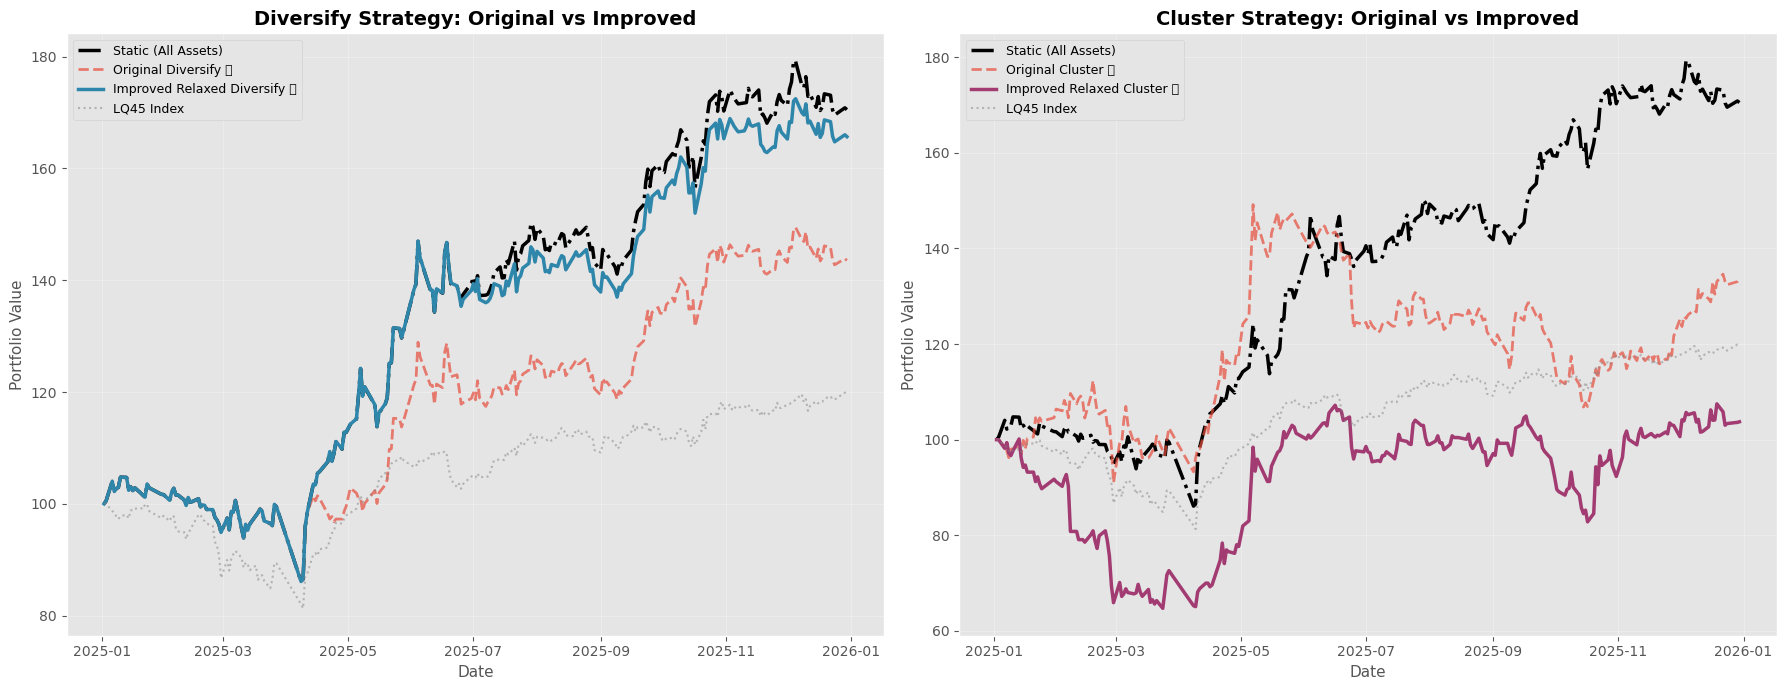


Visualization complete!


In [7]:
# Visualization: Diversify Comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: Diversify Comparison
ax1.plot(static_all.index, static_all['Portfolio_Value'], 
         label='Static (All Assets)', linewidth=2.5, color='black', linestyle='-.')
ax1.plot(original_diversify.index, original_diversify['Portfolio_Value'], 
         label='Original Diversify ❌', linewidth=2, color='#E74C3C', linestyle='--', alpha=0.7)
ax1.plot(relaxed_diversify.index, relaxed_diversify['Portfolio_Value'], 
         label='Improved Relaxed Diversify ✅', linewidth=2.5, color='#2E86AB')
ax1.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', linestyle=':', alpha=0.5)

ax1.set_title('Diversify Strategy: Original vs Improved', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Portfolio Value', fontsize=11)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: Cluster Comparison
ax2.plot(static_all.index, static_all['Portfolio_Value'], 
         label='Static (All Assets)', linewidth=2.5, color='black', linestyle='-.')
ax2.plot(original_cluster.index, original_cluster['Portfolio_Value'], 
         label='Original Cluster ❌', linewidth=2, color='#E74C3C', linestyle='--', alpha=0.7)
ax2.plot(relaxed_cluster.index, relaxed_cluster['Portfolio_Value'], 
         label='Improved Relaxed Cluster ✅', linewidth=2.5, color='#A23B72')
ax2.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', linestyle=':', alpha=0.5)

ax2.set_title('Cluster Strategy: Original vs Improved', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Portfolio Value', fontsize=11)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [8]:
# Risk Metrics Comparison

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

results_df = pd.DataFrame({
    'Static (All)': calculate_metrics(static_all['Portfolio_Value']),
    'Original Diversify': calculate_metrics(original_diversify['Portfolio_Value']),
    'Relaxed Diversify': calculate_metrics(relaxed_diversify['Portfolio_Value']),
    'Original Cluster': calculate_metrics(original_cluster['Portfolio_Value']),
    'Relaxed Cluster': calculate_metrics(relaxed_cluster['Portfolio_Value']),
    'LQ45 Index': calculate_metrics(lq45_idx)
}).T

print("\n=== RISK METRICS COMPARISON ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v61_improved_relaxed_mis_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS COMPARISON ===
                    Total Return (%)  Volatility (%)  Sharpe Ratio  \
Static (All)                   70.50           32.66          1.92   
Original Diversify             43.54           31.60          1.39   
Relaxed Diversify              65.66           32.56          1.83   
Original Cluster               33.71           39.01          0.99   
Relaxed Cluster                 3.74           42.49          0.30   
LQ45 Index                     19.44           20.38          1.04   

                    Max Drawdown (%)  
Static (All)                  -17.82  
Original Diversify            -17.82  
Relaxed Diversify             -17.82  
Original Cluster              -28.39  
Relaxed Cluster               -35.37  
LQ45 Index                    -18.70  

Results exported to: v61_improved_relaxed_mis_results.xlsx


## Kesimpulan

### Improvement Summary:

**Original Graph (V60) Problems:**
- Standard MIS terlalu agresif
- Terlalu sedikit aset terpilih
- High concentration risk
- Underperform vs Static baseline

**Relaxed MIS Solution:**
1. **Min Assets Constraint**: Ensure minimum 12 assets
2. **Adaptive Threshold**: Relax correlation if needed
3. **Incremental Selection**: Add assets iteratively

### Expected Improvements:

**Relaxed Diversify:**
- More assets → better diversification
- Closer to Static baseline performance
- Lower concentration risk
- Better Sharpe ratio

**Relaxed Cluster:**
- More assets → less extreme concentration
- Balance between clustering and diversification
- Better risk-adjusted return

### Key Insights:

**If Relaxed >> Original:**
- ✅ Min assets constraint is critical
- ✅ Standard MIS too aggressive for portfolios
- ✅ Need balance between filtering and diversification

**If Relaxed ≈ Static:**
- Graph filtering may not add value without AI
- Consider hybrid approaches
- AI timing might be necessary

### Next Steps:
1. Test Relaxed MIS **with AI timing** (combine V59 + V61)
2. Optimize min_assets parameter (try 10, 12, 15, 20)
3. Test adaptive threshold based on market volatility
4. Try hybrid approach (top-N + graph)